In [1]:
# @title Imports
import gymnasium as gym
from gymnasium.wrappers import RecordEpisodeStatistics
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import seaborn as sns
import matplotlib.pyplot as plt



from popy.simulation_tools import *
from popy.io_tools import load_behavior
from popy.behavior_data_tools import *
from popy.plotting.plotting_tools import *

from popy.simulation_helpers import simulate_agent, estimate_ll
from popy.config import COLORS, PROJECT_PATH_LOCAL

/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-o2ggrit2 because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
def load_res():
    # show bic and LPT values
    
    # load behavior data
    floc = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'results', 'optimizing', f'optimization_results.csv')
    res_temp = pd.read_csv(floc)

    # simulations
    sim_floc = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'results', 'optimizing', f'simulation_behaviors.pkl')
    sim_data = pd.read_pickle(sim_floc)
    sim_data['best_arm'] = sim_data['action'] == sim_data['best_arm']
    for model in res_temp['Model'].unique():
        prop_best_target = sim_data.loc[sim_data['model'] == model, 'best_arm'].mean()
        res_temp.loc[res_temp['Model'] == model, 'prop_best_target'] = prop_best_target

    return res_temp

def plot_res(res_all, paper_format=False):
    # Set font size and figure size
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        w, h = 4, 4
    else:
        plt.rcParams.update({'font.size': 8})
        w, h = 12, 5

    # Define the modes and figure
    modes = ['prop_best_target']
    fig, ax = plt.subplots(1, 1, figsize=(w/2.54, h/2.54))

    y_KA = 0.7742568470273881
    y_PO = 0.6373878299600445
    if not paper_format:
        ax.axhline(y=y_KA, color=COLORS['ka'], linestyle='--', linewidth=1, label='Monkey KA', zorder=10)
        ax.axhline(y=y_PO, color=COLORS['po'], linestyle='--', linewidth=1, label='Monkey PO', zorder=10)
    else:
        # add two bars for KA and PO monkeys by adding them to res_all dataframe with Model 'Monkey KA' and 'Monkey PO', and prop_best_target values y_KA and y_PO respectively, and then plot them as bars with the same color as the horizontal lines
        res_all = pd.concat([res_all, pd.DataFrame({'Model': ['Monkey KA'], 'prop_best_target': [y_KA]})], ignore_index=True)
        res_all = pd.concat([res_all, pd.DataFrame({'Model': ['Monkey PO'], 'prop_best_target': [y_PO]})], ignore_index=True)

        # mode monkeys to the first position
        res_all['Model'] = pd.Categorical(res_all['Model'], categories=['Monkey KA', 'Monkey PO'] + [model for model in res_all['Model'].unique() if model not in ['Monkey KA', 'Monkey PO']], ordered=True)
        res_all = res_all.sort_values('Model')

    # Get unique values
    models = res_all['Model'].unique()
    #monkeys = res_all.loc[res_all['monkey'] != 'yu_DCZ', 'monkey'].unique()

    # Set up positions
    x = np.arange(len(models))
    width = 0.65  # Width of bars        
    
    data = res_all
    values = [data.loc[data['Model'] == model, 'prop_best_target'].iloc[0] if len(data.loc[data['Model'] == model]) > 0 else 0 for model in models]
    
    # Create bars with model-based coloring
    for j, (model, value) in enumerate(zip(models, values)):
        hatch = None
        if model.split()[0] == 'Standard':
            # replace  what comes after with RL
            color = COLORS['Standard RL']
            if (not model == 'Standard RL - stickiness' and not paper_format) or (paper_format and not model == 'Standard RL'):
                hatch = '///'  # Dashed filling pattern
        elif model.split()[0] == 'Inferential':
            color = COLORS['Inferential RL']
            if (not model == 'Inferential RL - stickiness' and not paper_format) or (paper_format and not model == 'Inferential RL'):
                hatch = '///'  # Dashed filling pattern
        elif model.split()[0] == 'Foraging':
            color = COLORS['Foraging']
            if not len(model.split(" ")) == 1:
                hatch = '///'  # Dashed filling pattern
        else:
            color = COLORS.get(model, 'grey')
            hatch = None
        alpha = 0.8
        
        
        bar = ax.bar(x[j], value, width, 
            color=color, hatch=hatch,
            edgecolor='black', linewidth=0.5, alpha=alpha)
        
        # Set hatch color to grey for RL-s models
        if model.split()[-1] == 'RL-s':
            import matplotlib as mpl
            mpl.rcParams['hatch.color'] = 'grey'

    # plot horizontal lines: optimal, monkey KA and monkey PO:
    y_optimal = 0.89
    ax.axhline(y=y_optimal, color='black', linestyle='--', linewidth=1, label='Optimal', zorder=10)
    
    ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1), frameon=False)

    # Configure axes
    ax.set_ylim(0.40, 0.90)
    ax.set_yticks(np.arange(0.4, 1, 0.1))
    ax.set_ylabel('Prob. optimal target', fontsize=8)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    #ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

    ax.set_xticks(x)
    if paper_format:
        ax.set_xticklabels(models, rotation=45, horizontalalignment='right')
    else:
        ax.set_xticklabels(models, rotation=-90, horizontalalignment='center')    

    return fig, ax


res_all = load_res()
#res_all = res_all.sort_values(['Model', 'monkey'])

res_all

,Model,epsilon,alpha,alpha_unchosen,beta,V0,forgetting_rate,forgetting_threshold,stickiness_bias,b2,abandoned_bias,abandoned_decay,Reward rate,Proba best,alpha_threshold,prop_best_target
0,WSLS,0.003483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.48616,0.53406,NaN,0.53406
1,Repeating agent,0.047049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.40514,0.33514,NaN,0.33514
2,Standard RL - stickiness,NaN,0.831606,NaN,65.182717,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.54929,0.72275,NaN,0.72275
3,Standard RL,NaN,0.837458,NaN,88.508907,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.54917,0.72518,NaN,0.72518
4,Standard RL - forgetting,NaN,0.370099,NaN,70.047301,NaN,0.478145,0.254921,NaN,NaN,NaN,NaN,0.58341,0.80078,NaN,0.80078
5,Inferential RL - stickiness + spatial bias,NaN,0.146473,NaN,67.704908,NaN,NaN,NaN,3.295356,0.615347,NaN,NaN,0.58615,0.81077,NaN,0.81077
6,Standard RL - stickiness + forgetting,NaN,0.279223,NaN,86.148340,NaN,0.201793,0.322275,0.000000,NaN,NaN,NaN,0.58775,0.81198,NaN,0.81198
7,Inferential RL - stickiness + multiple alphas,NaN,0.038855,0.324777,100.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.58707,0.80977,NaN,0.80977
8,Foraging,NaN,0.301073,NaN,100.000000,0.302745,NaN,NaN,NaN,NaN,NaN,NaN,0.57490,0.78434,NaN,0.78434
9,Inferential RL - stickiness,NaN,0.155827,NaN,75.936239,NaN,NaN,NaN,8.838768,NaN,NaN,NaN,0.58530,0.81050,NaN,0.81050


In [3]:
# sort by the order of keys in MODELS (dumb solution)

from run_model_optimizing import MODELS

model_order = list(MODELS.keys())
res_all['Model'] = pd.Categorical(res_all['Model'], categories=model_order, ordered=True)
res_all = res_all.sort_values('Model')
res_all

,Model,epsilon,alpha,alpha_unchosen,beta,V0,forgetting_rate,forgetting_threshold,stickiness_bias,b2,abandoned_bias,abandoned_decay,Reward rate,Proba best,alpha_threshold,prop_best_target
1,Repeating agent,0.047049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.40514,0.33514,NaN,0.33514
0,WSLS,0.003483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.48616,0.53406,NaN,0.53406
3,Standard RL,NaN,0.837458,NaN,88.508907,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.54917,0.72518,NaN,0.72518
2,Standard RL - stickiness,NaN,0.831606,NaN,65.182717,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.54929,0.72275,NaN,0.72275
4,Standard RL - forgetting,NaN,0.370099,NaN,70.047301,NaN,0.478145,0.254921,NaN,NaN,NaN,NaN,0.58341,0.80078,NaN,0.80078
6,Standard RL - stickiness + forgetting,NaN,0.279223,NaN,86.148340,NaN,0.201793,0.322275,0.000000,NaN,NaN,NaN,0.58775,0.81198,NaN,0.81198
10,Inferential RL,NaN,0.125499,NaN,93.958247,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.58262,0.80378,NaN,0.80378
9,Inferential RL - stickiness,NaN,0.155827,NaN,75.936239,NaN,NaN,NaN,8.838768,NaN,NaN,NaN,0.58530,0.81050,NaN,0.81050
5,Inferential RL - stickiness + spatial bias,NaN,0.146473,NaN,67.704908,NaN,NaN,NaN,3.295356,0.615347,NaN,NaN,0.58615,0.81077,NaN,0.81077
7,Inferential RL - stickiness + multiple alphas,NaN,0.038855,0.324777,100.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.58707,0.80977,NaN,0.80977


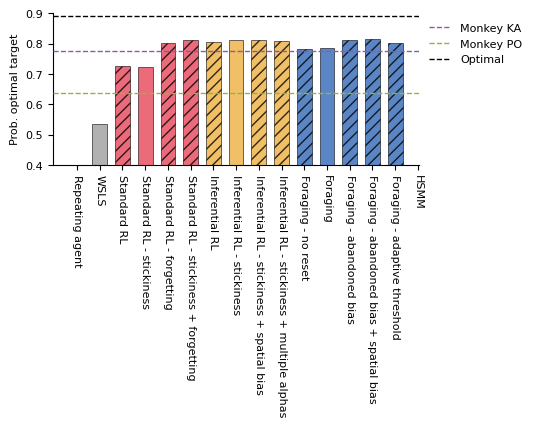

In [4]:

fig, ax = plot_res(res_all, paper_format=False)

# Adjust layout and save as SVG if needed
#plt.tight_layout()
# Uncomment the following line to save the figure
plt.savefig(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'figs', 'optimal_models.png'), dpi=300, bbox_inches='tight', transparent=False)

plt.show()

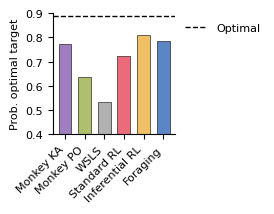

In [5]:
models_to_show = {
    'WSLS': 'WSLS',
    'Standard RL - stickiness': 'Standard RL',
    'Inferential RL - stickiness': 'Inferential RL',
    'Foraging': 'Foraging',
}

res_all_temp = res_all[res_all['Model'].isin(models_to_show.keys())].copy()
res_all_temp['Model'] = res_all_temp['Model'].map(models_to_show)

fig, ax = plot_res(res_all_temp, paper_format=True)

# Adjust layout and save as SVG if needed
#plt.tight_layout()
# Uncomment the following line to save the figure
plt.savefig(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'figs', 'optimal_models_paper.svg'), dpi=300, bbox_inches='tight', transparent=False)

plt.show()